# Sweet Lift Taxi: Predicting Taxi Demand at Airports

# Contents <a id='contents'></a>

[1. Contents](#contents)   
[2. Introduction](#introduction)  
[3. Project Goal](#project_goal)     
[4. Initialization](#initialization)  
[5. Load data & Data description ](#load-data)   
[6. Data Preparation](#data-preparation)   
[7. Model Analysis](#model-analysis)    
[8. Model Training](#model-training)  
[9. Model Testing](#model-testing)  
[10. Conclusion](#conclusion)  

# 1. Introduction <a id='introduction'></a> 
[Back to Contents](#contents)

In the bustling world of transportation and mobility services, **Sweet Lift Taxi** company aims **to optimize its operations and attract more drivers during peak hours at airports**. To achieve this goal, the company seeks to develop a predictive model that can accurately forecast the number of taxi orders for the next hour at various airport locations. This predictive model will not only help Sweet Lift Taxi efficiently allocate resources but also provide passengers with quicker access to taxis during high-demand periods.

# 2. Project Goal <a id='project_goal'></a>  
[Back to Contents](#contents)

The primary objective of this project is **to build a predictive model capable of estimating the number of taxi orders for the next hour**. To measure the model's performance, we aim to achieve a **Root Mean Square Error (RMSE) metric on the test set that does not exceed 48**. RMSE is a widely-used evaluation metric in regression tasks and will provide an effective means to assess the accuracy of our predictions.

# 3. Initialization <a id='initialization'></a>  
[Back to Contents](#contents)

In [1]:
# Import libraries for data preprocessing & manipulation
import numpy as np
import pandas as pd

# Import libraries / modules for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import methods for model analysis
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

# Import methods for splitting & cross-validation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import TimeSeriesSplit

# Import method to measure quality of the model
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Import machine learning models for Regression task
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

# 4. Load data & Data description <a id='load-data'></a>  
[Back to Contents](#contents)

The data is stored in file `./datasets/taxi.csv`. Let's load the data from the csv file, while making the first column (date column) as index and parsing the date column to `datetime` datatype:

In [ ]:
# Load the data
df_taxi = pd.read_csv('./datasets/taxi.csv', index_col=[0], parse_dates=[0])

Great! Let's have a peek into the data:

In [3]:
# Get first 10 records from the Dataframe - df_taxi
df_taxi.head(10)

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32
2018-03-01 00:50:00,21
2018-03-01 01:00:00,7
2018-03-01 01:10:00,5
2018-03-01 01:20:00,17


Let's also get some general information about the Dataframe - `df_taxi`:

In [4]:
# Get general information about the Dataframe
df_taxi.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


The DataFrame - `df_taxi` contains a time series data (`26,496` entries) spanning from March 1, 2018, to August 31, 2018, for every 10 minutes. The DataFrame consists of only one column, labeled `num_orders`, which stores integer values representing **the number of taxi orders**. The datatype of the `num_orders` column is `int64` that seems apt.

# 5. Data Preparation <a id='data-preparation'></a>  
[Back to Contents](#contents)

Let's get some general information and stats about the data, first:

In [5]:
# Get first 10 rows from the dataset
df_taxi.head(10)

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32
2018-03-01 00:50:00,21
2018-03-01 01:00:00,7
2018-03-01 01:10:00,5
2018-03-01 01:20:00,17


In [6]:
# Get the shape of the dataset
df_taxi.shape

(26496, 1)

In [7]:
# Get the descriptive statistics of the dataset
df_taxi.describe()

,num_orders
count,26496.000000
mean,14.070463
std,9.211330
min,0.000000
25%,8.000000
50%,13.000000
75%,19.000000
max,119.000000


Let's sort the data according to the datetime index, to make sure that we have data arranged sequentially:

In [8]:
# Sort data according to the datetime
df_taxi.sort_index(axis=0, inplace=True)

In [9]:
# Check if the dates are in chronological order
df_taxi.index.is_monotonic

True

Great! Now, we have records in our time series DataFrame sorted in ascending order. Let's have a quick peek into the DataFrame once again:

In [10]:
# Get the first 10 records of the DataFrame
df_taxi.head(10)

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32
2018-03-01 00:50:00,21
2018-03-01 01:00:00,7
2018-03-01 01:10:00,5
2018-03-01 01:20:00,17


Awesome! Now, let's plot and see how our time series data looks like:

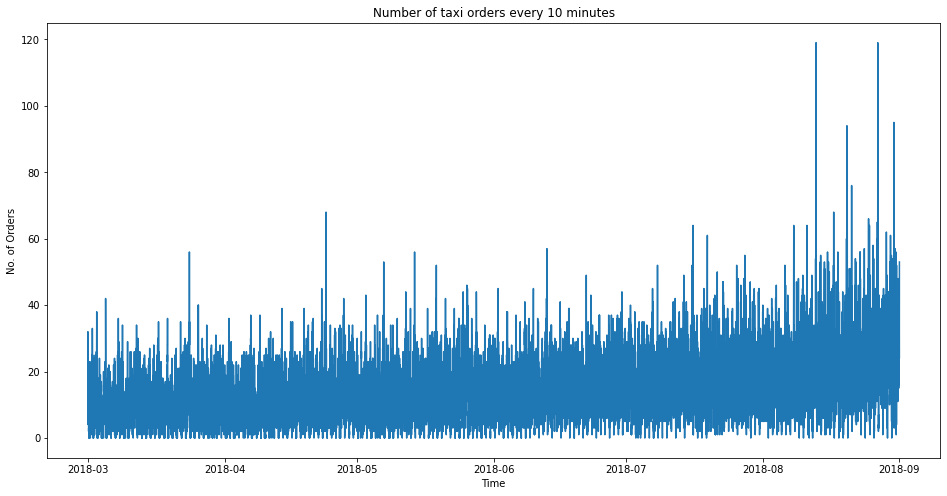

In [11]:
# Plot the time series data
plt.figure(figsize=(16,8))
plt.title('Number of taxi orders every 10 minutes')
plt.xlabel('Time')
plt.ylabel('No. of Orders')
plt.plot(df_taxi);

Wow! The graph above definitely seems to have some trends but feel like it would be much easier to understand the data if we resample it on hourly basis. And also since we are to build a predictive model capable of estimating the number of taxi orders for the next hour, the resampling feels apt.

## Resample the data on hourly basis

Let's resample the data on hourly basis such that our time series will have an interval of 1 hour:

In [12]:
# Resample the data by an interval of 1 hour
df_taxi = df_taxi.resample('1H').sum()

Great! Let's have a peek into the data now:

In [13]:
# Get the first 10 records of the DataFrame
df_taxi.head(10)

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43
2018-03-01 05:00:00,6
2018-03-01 06:00:00,12
2018-03-01 07:00:00,15
2018-03-01 08:00:00,34


It definitely looks as though the dataset was successfully resampled. Let's get the minimum and maximum datatime of the data:

In [14]:
# Get minimum datetime
df_taxi.index.min()

Timestamp('2018-03-01 00:00:00', freq='H')

In [15]:
# Get maximum datetime
df_taxi.index.max()

Timestamp('2018-08-31 23:00:00', freq='H')

Looks like we are making some progress. Let's visualize the time series once again:

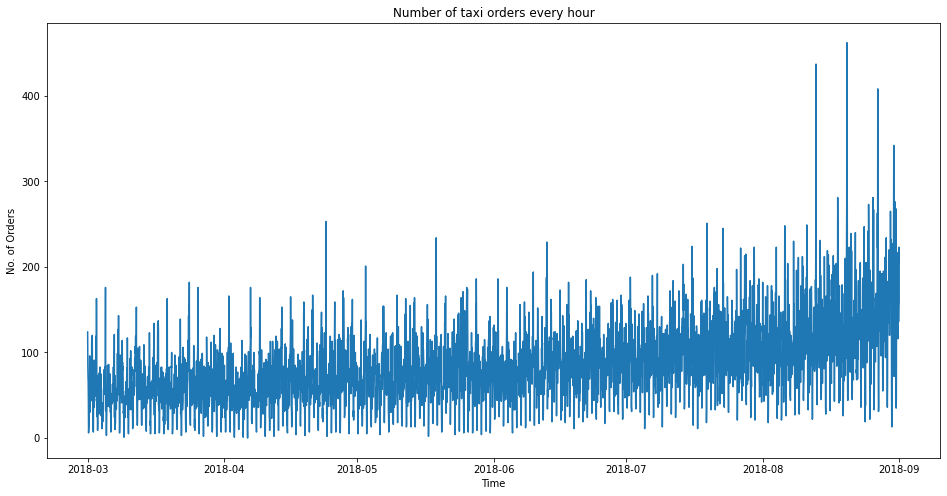

In [16]:
# Plot the time series data
plt.figure(figsize=(16,8))
plt.title('Number of taxi orders every hour')
plt.xlabel('Time')
plt.ylabel('No. of Orders')
plt.plot(df_taxi);

# 6. Model Analysis <a id='model-analysis'></a>  
[Back to Contents](#contents)

Now, since we 've our data resmapled with an interval of 1 hour, let's try to analyze our time series and understand its nature:

## Calculate Rolling Mean for the Time Series

Let's smoothen the original time series to identify trends. Pandas has an implementation available with `DataFrame.rolling(window).mean()`. The wider the window, the smoother the trend. In the case of very noisy data, this procedure can help detect common patterns.

In [17]:
#Source: https://www.kaggle.com/kashnitsky/topic-9-part-1-time-series-analysis-in-python

def plotMovingAverage(series, window, plot_intervals=False, scale=1.96, plot_anomalies=False):

    """
        series - dataframe with timeseries
        window - rolling window size 
        plot_intervals - show confidence intervals
        plot_anomalies - show anomalies 

    """
    rolling_mean = series.rolling(window=window).mean()

    plt.figure(figsize=(15,5))
    plt.title("Moving average\n window size = {}".format(window))
    plt.plot(rolling_mean, "g", label="Rolling mean trend")

    # Plot confidence intervals for smoothed values
    if plot_intervals:
        mae = mean_absolute_error(series[window:], rolling_mean[window:])
        deviation = np.std(series[window:] - rolling_mean[window:])
        lower_bond = rolling_mean - (mae + scale * deviation)
        upper_bond = rolling_mean + (mae + scale * deviation)
        plt.plot(upper_bond, "r--", label="Upper Bond / Lower Bond")
        plt.plot(lower_bond, "r--")
        
        # Having the intervals, find abnormal values
        if plot_anomalies:
            anomalies = pd.DataFrame(index=series.index, columns=series.columns)
            anomalies[series<lower_bond] = series[series<lower_bond]
            anomalies[series>upper_bond] = series[series>upper_bond]
            plt.plot(anomalies, "ro", markersize=10)
        
    plt.plot(series[window:], label="Actual values", alpha=0.5)
    plt.legend(loc="upper left")
    plt.grid(True)

Let's smooth the data by the previous 60 hours:

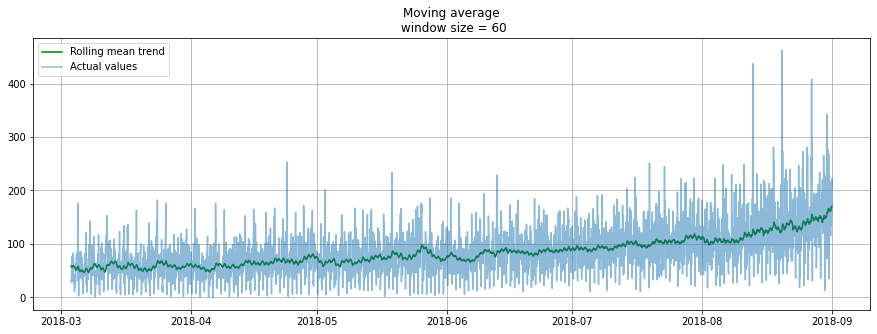

In [18]:
# Smoothen the time series by a window size of 60 hours
plotMovingAverage(df_taxi, 60)

The above plot shows us that there is indeed an increase in the number of orders from March, 2018 to September, 2018. But, let's calculate the rolling mean for time series data ressampled for an interval of 1 day, to have a more clear picture:

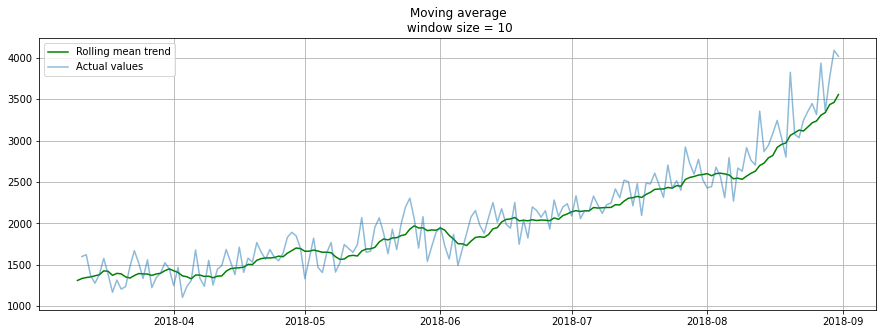

In [19]:
# Smoothen the time series by a window size of 10 days
plotMovingAverage(df_taxi.resample('1D').sum(), 10)

Wow! That gives a much clearer picture for sure and confirms that **there is indeed an increase in the number of taxi orders from March, 2018 to September, 2018**.

Let's also plot confidence intervals for our smoothed values:

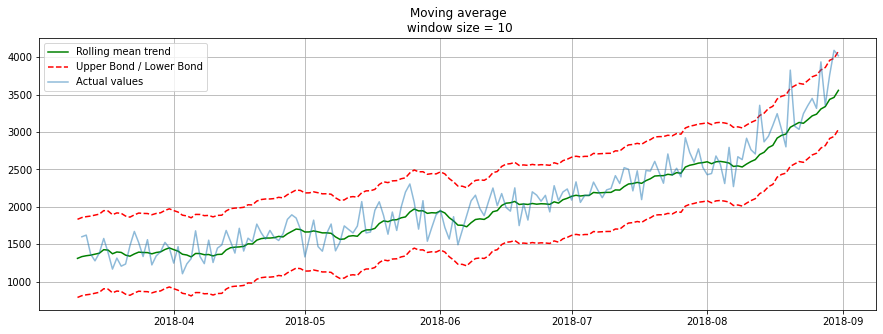

In [20]:
# Smoothen the time series by a window size of 10 days
plotMovingAverage(df_taxi.resample('1D').sum(), 10, plot_intervals=True)

Now, let's try to **check if we have any anomalies in our time series dataset** with the help of moving average:

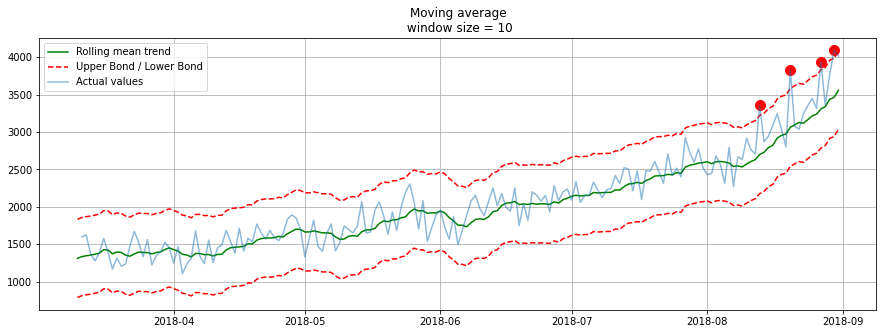

In [21]:
# Detect any anomaly in the time series dataset
plotMovingAverage(df_taxi.resample('1D').sum(), 10, plot_intervals=True, plot_anomalies=True)

Well! Our data has some anomalies for sure. While training our models, we need to keep that in mind.

## Analyze Trends and Seasonality of the Time Series

To better understand our time series data, let's look into trends and seasonality. A **trend** is a smooth change of the mean value of the series without repeating patterns. **Seasonality** means cyclically repeating patterns in a time series.

The `tsa.seasonal` (`tsa` stands for _time series analysis_) module of the `statsmodels` library contains the function `seasonal_decompose()`. This function breaks the series into three components: **trend**, **seasonality**, and **residuals**. The residuals component cannot be explained by trend and seasonality and is essentially just noise.

Let's get the trend, seasonality and residuals of our time series dataset:

In [22]:
# Decompose the time series dataset into trend, seasonality and residuals
decomposed = seasonal_decompose(df_taxi, 'additive')

Let's plot the trend, seasonality and residuals of the time series data:

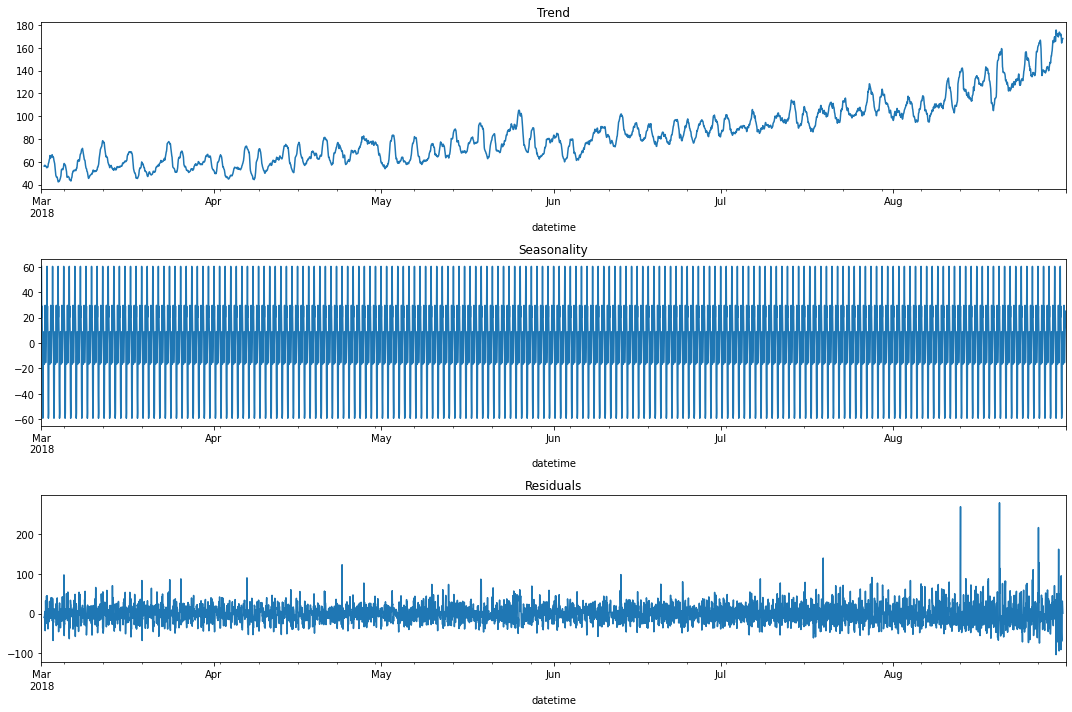

In [23]:
# Set the figure size
plt.figure(figsize=(6, 8))

# Plot the Trend
plt.subplot(311)
decomposed.trend.plot(ax=plt.gca(), figsize=(15, 10))
plt.title('Trend')

# Plot the Seasonality 
plt.subplot(312)
decomposed.seasonal.plot(ax=plt.gca(), figsize=(15, 10))
plt.title('Seasonality')

# Plot the Residuals
plt.subplot(313)
decomposed.resid.plot(ax=plt.gca(), figsize=(15, 10))
plt.title('Residuals')
plt.tight_layout()
plt.show()

We can clearly see that our time series data has an upward trend and there is indeed a repeating pattern in the data. But, to have a more clear picture, **let's get trend, seasonality and residuals of the time series data resampled by 1 day**:

In [24]:
# Decompose the time series dataset into trend, seasonality and residuals
decomposed = seasonal_decompose(df_taxi.resample('1D').sum(), 'additive')

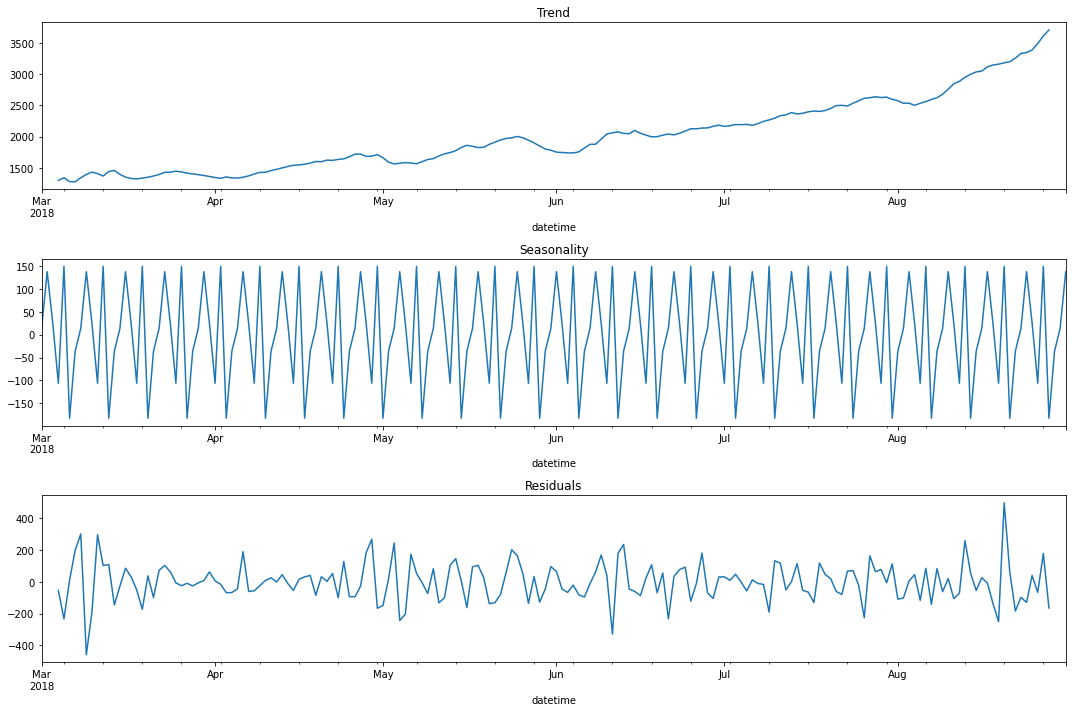

In [25]:
# Set the figure size
plt.figure(figsize=(6, 8))

# Plot the Trend
plt.subplot(311)
decomposed.trend.plot(ax=plt.gca(), figsize=(15, 10))
plt.title('Trend')

# Plot the Seasonality 
plt.subplot(312)
decomposed.seasonal.plot(ax=plt.gca(), figsize=(15, 10))
plt.title('Seasonality')

# Plot the Residuals
plt.subplot(313)
decomposed.resid.plot(ax=plt.gca(), figsize=(15, 10))
plt.title('Residuals')
plt.tight_layout()
plt.show()

The trend here shows that the number of orders have been increasing no doubt. And the seasonalaty shows the amplitude of the swings, which is around 310 (from +150 to -160). 

Let's look for **trend, seasonality and residuals of the time series data resampled by 1 day for a period of three weeks**, to see **how the number of orders changes throughout the week**. We'll look into the data from **March 4th, 2018 to March 24th, 2018**: 

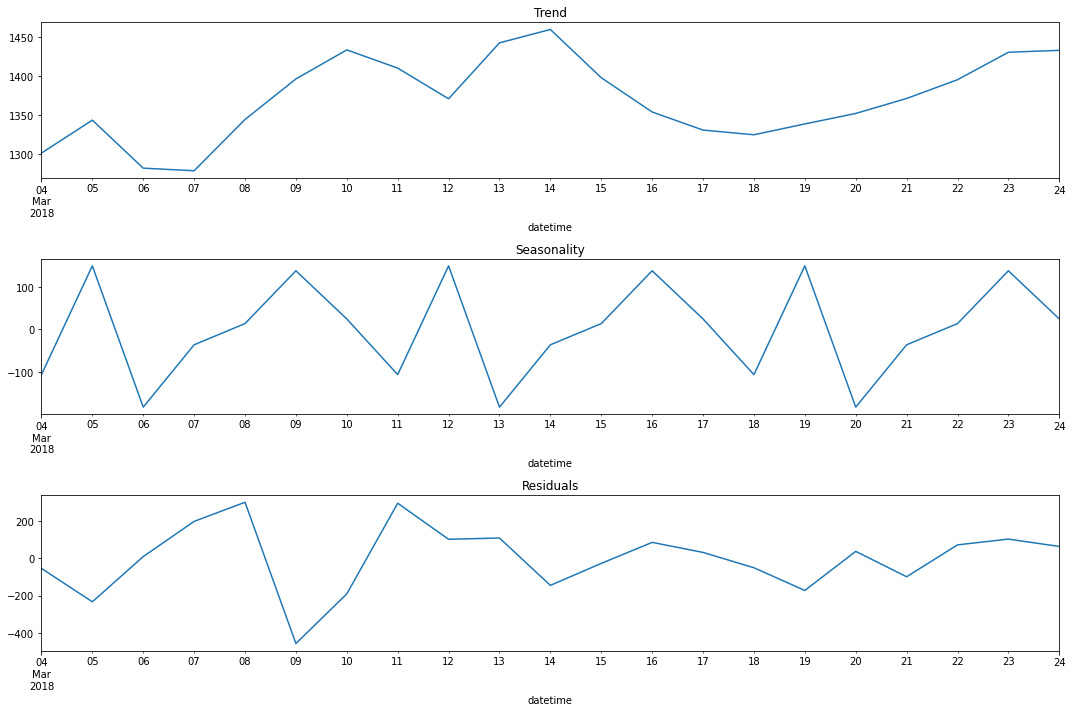

In [26]:
# Set the figure size
plt.figure(figsize=(6, 8))

# Plot the Trend
plt.subplot(311)
decomposed.trend['2018-03-04':'2018-03-24'].plot(ax=plt.gca(), figsize=(15, 10))
plt.title('Trend')

# Plot the Seasonality 
plt.subplot(312)
decomposed.seasonal['2018-03-04':'2018-03-24'].plot(ax=plt.gca(), figsize=(15, 10))
plt.title('Seasonality')

# Plot the Residuals
plt.subplot(313)
decomposed.resid['2018-03-04':'2018-03-24'].plot(ax=plt.gca(), figsize=(15, 10))
plt.title('Residuals')
plt.tight_layout()
plt.show()

The seasonality of the data of the period of three weeks from **March 4th, 2018 to March 24th, 2018** shows interesting results. It seems **the number of taxi orders are high on Mondays and Fridays**.

We can re-validate the findings by looking at the data of the period of three weeks from **August 5th, 2018 to August 25th, 2018**:

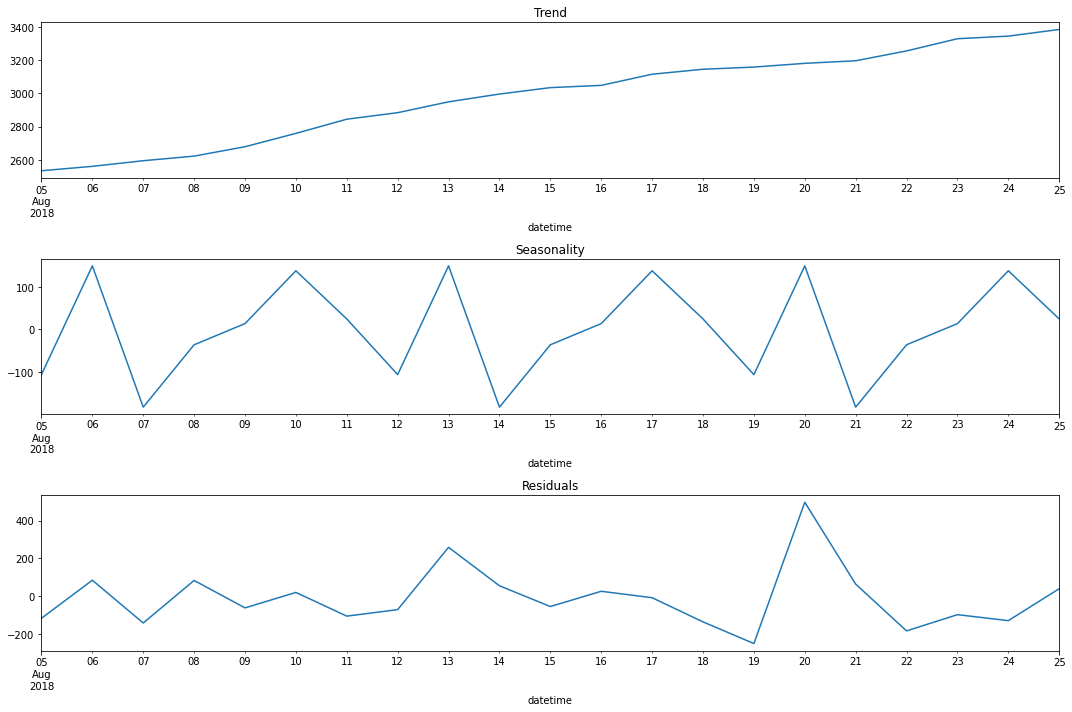

In [27]:
# Set the figure size
plt.figure(figsize=(6, 8))

# Plot the Trend
plt.subplot(311)
decomposed.trend['2018-08-05':'2018-08-25'].plot(ax=plt.gca(), figsize=(15, 10))
plt.title('Trend')

# Plot the Seasonality 
plt.subplot(312)
decomposed.seasonal['2018-08-05':'2018-08-25'].plot(ax=plt.gca(), figsize=(15, 10))
plt.title('Seasonality')

# Plot the Residuals
plt.subplot(313)
decomposed.resid['2018-08-05':'2018-08-25'].plot(ax=plt.gca(), figsize=(15, 10))
plt.title('Residuals')
plt.tight_layout()
plt.show()

The seasonality of the data of the period of three weeks from **August 5th, 2018 to August 25th, 2018** hints the same thing that **the number of taxi orders are high on Mondays and Fridays**.

Great! Now, l**et's look for trend, seasonality and residuals of the time series data resampled by 1 hour for a period of one week**, to see **how the number of orders changes throughout different times of the day**. We'll look into the data from **April 8th, 2018 to April 14th, 2018**:

In [28]:
# Decompose the time series dataset into trend, seasonality and residuals
decomposed = seasonal_decompose(df_taxi, 'additive')

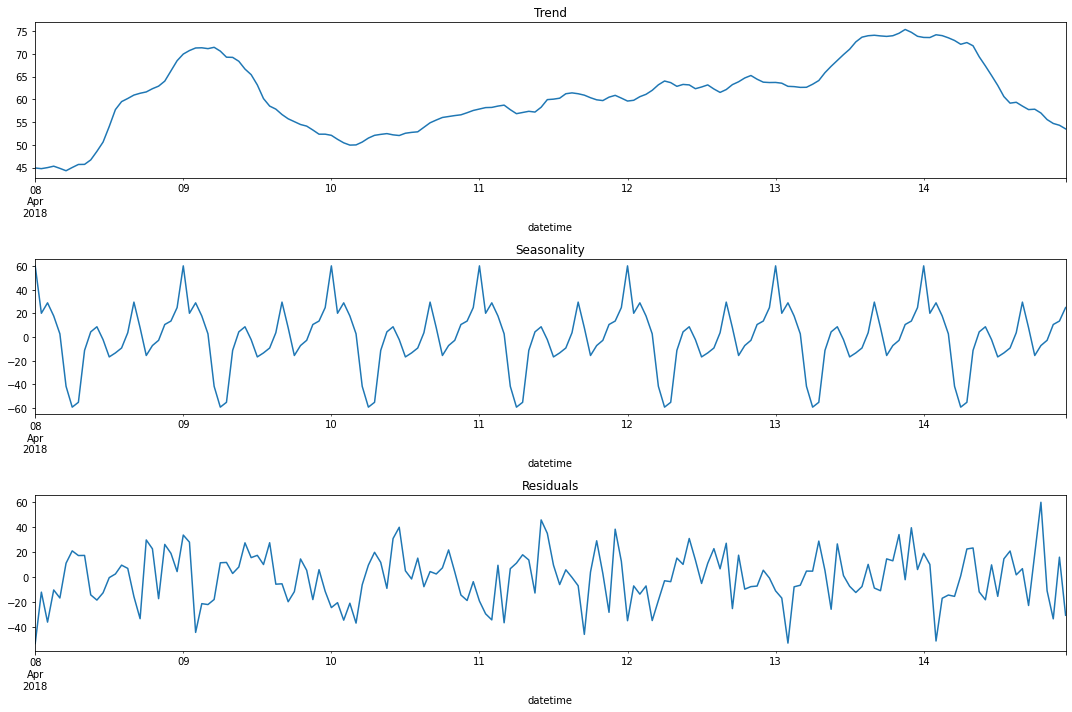

In [29]:
# Set the figure size
plt.figure(figsize=(6, 8))

# Plot the Trend
plt.subplot(311)
decomposed.trend['2018-04-08':'2018-04-14'].plot(ax=plt.gca(), figsize=(15, 10))
plt.title('Trend')

# Plot the Seasonality 
plt.subplot(312)
decomposed.seasonal['2018-04-08':'2018-04-14'].plot(ax=plt.gca(), figsize=(15, 10))
plt.title('Seasonality')

# Plot the Residuals
plt.subplot(313)
decomposed.resid['2018-04-08':'2018-04-14'].plot(ax=plt.gca(), figsize=(15, 10))
plt.title('Residuals')
plt.tight_layout()
plt.show()

The seasonality of the data of the period of one week from April 8th, 2018 to April 14th, 2018 shows that **the number of taxi orders are higher at the start of the day and then, decreases suddenly and increases again by the later part of the day.**

## Analyze Autocorrelation

As per the [Autocorrelation and Partial Autocorrelation in Time Series Data](https://statisticsbyjim.com/time-series/autocorrelation-partial-autocorrelation/):

**Autocorrelation** is the **correlation between two values in a time series**. In other words, the time series data correlate with themselves—hence, the name. The autocorrelation function (ACF) assesses the correlation between observations in a time series for a set of lags.

We can use the autocorrelation function (ACF) **to identify which lags have significant correlations, understand the patterns and properties of the time series, and then use that information to model the time series data**. From the ACF, we can assess the randomness and stationarity of a time series. We can also determine whether trends and seasonal patterns are present.

In an ACF plot, each bar represents the size and direction of the correlation. Bars that extend across the red line are statistically significant.

- **Randomness/White Noise**   
For random data, autocorrelations should be near zero for all lags.

- **Stationarity**   
Stationarity means that the time series does not have a trend, has a constant variance, a constant autocorrelation pattern, and no seasonal pattern. The autocorrelation function declines to near zero rapidly for a stationary time series. In contrast, the ACF drops slowly for a non-stationary time series.

- **Trends**  
When trends are present in a time series, shorter lags typically have large positive correlations because observations closer in time tend to have similar values. The correlations taper off slowly as the lags increase.

- **Seasonality**  
When seasonal patterns are present, the autocorrelations are larger for lags at multiples of the seasonal frequency than for other lags.

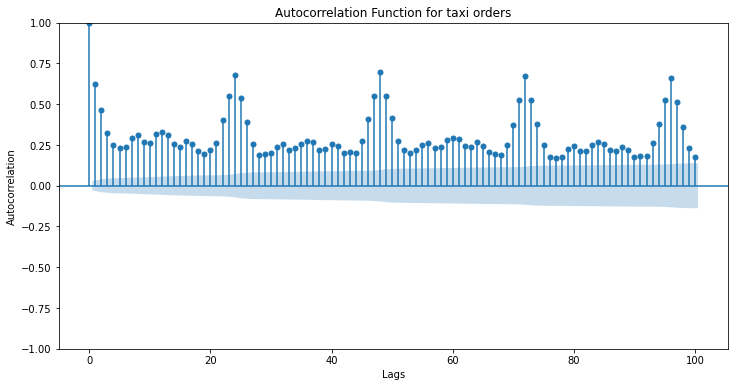

In [30]:
# Plot the autocorrelation function for the time series resampled by 1H
fig, ax = plt.subplots(figsize=(12, 6))
plot_acf(df_taxi, lags = 100, title='Autocorrelation Function for taxi orders', ax=ax)
plt.ylabel('Autocorrelation')
plt.xlabel('Lags')
plt.show()

From the plot of the autocorrelation function for the time series resampled by 1 hour, we could see that **the autocorrelations are larger for lags at multiples of the seasonal frequency than for other lags**. Thus, we can conclude that the seasonal patterns are present in the time series data.

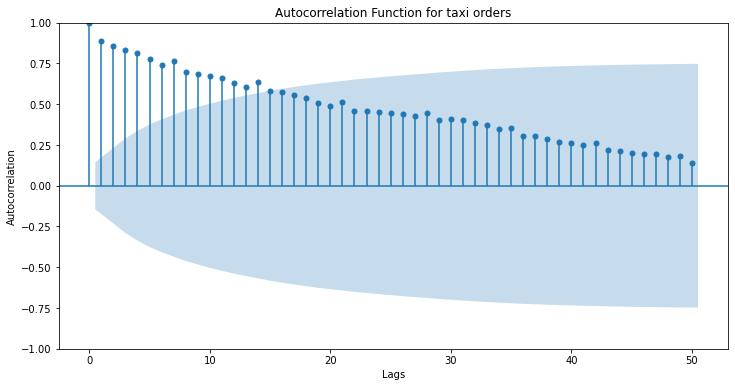

In [31]:
# Plot the autocorrelation function for the time series resampled by 1D
fig, ax = plt.subplots(figsize=(12, 6))
plot_acf(df_taxi.resample('1D').sum(), lags = 50, title='Autocorrelation Function for taxi orders', ax=ax)
plt.ylabel('Autocorrelation')
plt.xlabel('Lags')
plt.show()

From the plot of the autocorrelation function for the time series resampled by 1 day, we can see that **the shorter lags are having large positive correlations. The correlations are tapering off slowly as the lags increase**. This indicates that the time series have trends too.

# 7. Model Training <a id='model-training'></a>  
[Back to Contents](#contents)

## Feature engineering

We will now create new **Calendar features** for our time series dataset - `month`, `day`, `day_of_week` and `hour` from the `datetime` index. We will also create **Lag features** as the previous values in the time series will tell us whether the function `x(t)` will grow or decrease.  

Let's write a function for the same:

In [32]:
# Function to make new calendar and lag features
def make_features(df, max_lag, rolling_mean_size):
    # Function takes:
    # 1. df - DataFrame
    # 2. max_lag - maximum lag size
    # 3. rolling_mean_size - window size for calculating rolling mean
    
    # Create calendar features   
    df['month'] = df.index.month
    df['day'] = df.index.day
    df['day_of_week'] = df.index.dayofweek
    df['hour'] = df.index.hour

    # Create lag features from 1 to max_lag
    for lag in range(1, max_lag + 1):
        df['lag_{}'.format(lag)] = df['num_orders'].shift(lag)

    # Calculate rolling mean by excluding the current value for the window size of rolling_mean_size
    df['rolling_mean'] = (
        df['num_orders'].shift().rolling(rolling_mean_size).mean()
    )

Let's now create features with maximum lag of `8` and the window size of rolling mean being `10`:

In [33]:
# Create new features
make_features(df_taxi, 8, 10)

Awesome! Let's have a peek into the data:

In [34]:
# Get the first 15 records from the DataFrame
df_taxi.head(15)

,num_orders,month,day,day_of_week,hour,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,rolling_mean
datetime,,,,,,,,,,,,,,
2018-03-01 00:00:00,124,3,1,3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 01:00:00,85,3,1,3,1,124.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 02:00:00,71,3,1,3,2,85.0,124.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 03:00:00,66,3,1,3,3,71.0,85.0,124.0,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 04:00:00,43,3,1,3,4,66.0,71.0,85.0,124.0,NaN,NaN,NaN,NaN,NaN
2018-03-01 05:00:00,6,3,1,3,5,43.0,66.0,71.0,85.0,124.0,NaN,NaN,NaN,NaN
2018-03-01 06:00:00,12,3,1,3,6,6.0,43.0,66.0,71.0,85.0,124.0,NaN,NaN,NaN
2018-03-01 07:00:00,15,3,1,3,7,12.0,6.0,43.0,66.0,71.0,85.0,124.0,NaN,NaN
2018-03-01 08:00:00,34,3,1,3,8,15.0,12.0,6.0,43.0,66.0,71.0,85.0,124.0,NaN


In [35]:
# Get the last 15 records from the DataFrame
df_taxi.tail(15)

,num_orders,month,day,day_of_week,hour,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,rolling_mean
datetime,,,,,,,,,,,,,,
2018-08-31 09:00:00,203,8,31,4,9,182.0,46.0,35.0,78.0,268.0,99.0,230.0,194.0,165.4
2018-08-31 10:00:00,191,8,31,4,10,203.0,182.0,46.0,35.0,78.0,268.0,99.0,230.0,161.1
2018-08-31 11:00:00,167,8,31,4,11,191.0,203.0,182.0,46.0,35.0,78.0,268.0,99.0,152.6
2018-08-31 12:00:00,136,8,31,4,12,167.0,191.0,203.0,182.0,46.0,35.0,78.0,268.0,149.9
2018-08-31 13:00:00,166,8,31,4,13,136.0,167.0,191.0,203.0,182.0,46.0,35.0,78.0,140.5
2018-08-31 14:00:00,133,8,31,4,14,166.0,136.0,167.0,191.0,203.0,182.0,46.0,35.0,147.2
2018-08-31 15:00:00,116,8,31,4,15,133.0,166.0,136.0,167.0,191.0,203.0,182.0,46.0,133.7
2018-08-31 16:00:00,197,8,31,4,16,116.0,133.0,166.0,136.0,167.0,191.0,203.0,182.0,137.5
2018-08-31 17:00:00,217,8,31,4,17,197.0,116.0,133.0,166.0,136.0,167.0,191.0,203.0,153.7


Great! So, we have successfully created all the required calendar and lag features along with the rolling mean, but now we have few records in the starting of the DataFrame that have null values. **Let's drop the observations or rows where we have null values**:

In [36]:
# Drop records with null values
df_taxi = df_taxi.dropna()

In [37]:
# Get the first 15 records from the DataFrame
df_taxi.head(15)

,num_orders,month,day,day_of_week,hour,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,rolling_mean
datetime,,,,,,,,,,,,,,
2018-03-01 10:00:00,64,3,1,3,10,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,52.5
2018-03-01 11:00:00,96,3,1,3,11,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,46.5
2018-03-01 12:00:00,30,3,1,3,12,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,47.6
2018-03-01 13:00:00,32,3,1,3,13,30.0,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.5
2018-03-01 14:00:00,48,3,1,3,14,32.0,30.0,96.0,64.0,69.0,34.0,15.0,12.0,40.1
2018-03-01 15:00:00,66,3,1,3,15,48.0,32.0,30.0,96.0,64.0,69.0,34.0,15.0,40.6
2018-03-01 16:00:00,43,3,1,3,16,66.0,48.0,32.0,30.0,96.0,64.0,69.0,34.0,46.6
2018-03-01 17:00:00,44,3,1,3,17,43.0,66.0,48.0,32.0,30.0,96.0,64.0,69.0,49.7
2018-03-01 18:00:00,73,3,1,3,18,44.0,43.0,66.0,48.0,32.0,30.0,96.0,64.0,52.6


Awesome! So, let's see now how many observations / rows and features / columns do we have now:

In [38]:
# Get the number of observations and features in the DataFrame
df_taxi.shape

(4406, 14)

**We have 4406 rows and 14 columns**.

## Split the dataset into training and test sets

Let's split the dataset into training and test sets. The test sample should be 10% of the initial dataset. The `train_test_split()` function from the `sklearn.model_selection` module mixes data by default, so let's set the `shuffle` argument to `False` so the data can be separated correctly into training and test sets:

In [39]:
# Split the dataset into training & testing sets
train, test = train_test_split(df_taxi, shuffle=False, test_size=0.1)

Let's validate if the split was in order:

In [40]:
print(f'The training set ranges from {train.index.min()} to {train.index.max()}.')
print(f'The test set ranges from {test.index.min()} to {test.index.max()}.')

The training set ranges from 2018-03-01 10:00:00 to 2018-08-13 14:00:00.
The test set ranges from 2018-08-13 15:00:00 to 2018-08-31 23:00:00.


That looks great! Let's proceed.

## Define the targets and features in the datasets

Let's now define the targets and features in the training and test datasets:

In [41]:
# Define the targets and features in the datasets
features_train = train.drop(['num_orders'], axis=1)
target_train = train['num_orders']

features_test = test.drop(['num_orders'], axis=1)
target_test = test['num_orders']

## Define the test metric

Our test metric is RMSE. Let's define a function for that before proceeding:

In [42]:
# Function to calculate Root Mean Squared Error
def calc_rmse(true, pred):
    return mean_squared_error(true, pred)**0.5

## Define helper functions

Let's also define few functions to automate our tasks:

In [43]:
# Function to plot the residuals for the target
def plot_residuals(target, pred):
    ax = np.abs(target - pred).hist(bins = 50, figsize=(12,8))
    ax.set_title('Residuals plot for the target')

In [44]:
# Function to plot the true target values vs predicted target values
def plot_true_vs_predictions(features, target_true, target_pred):
    plt.figure(figsize=(15, 8))
    plt.plot(features.index, target_pred, alpha=0.7)
    plt.plot(features.index, target_true, color='red', alpha=0.3)
    plt.ylabel('No of taxi orders')
    plt.xlabel('Dates')
    plt.xticks(rotation = 45)
    plt.legend(['Prediction', 'Target'])
    plt.title('True target values vs Predicted target values')

## Train the models

To tune the hyperparameters, we make use of the time series split for cross validation:

In [45]:
tscv = TimeSeriesSplit(n_splits=5)
tscv

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)

### Linear Regressor Model

Great! So, now we'll train, predict and evaluate the **Linear Regression Model**:

RMSE using Linear Regression
--------------------------------------------------
RMSE:  53.26605628855383
CPU times: user 234 ms, sys: 76.4 ms, total: 311 ms
Wall time: 344 ms


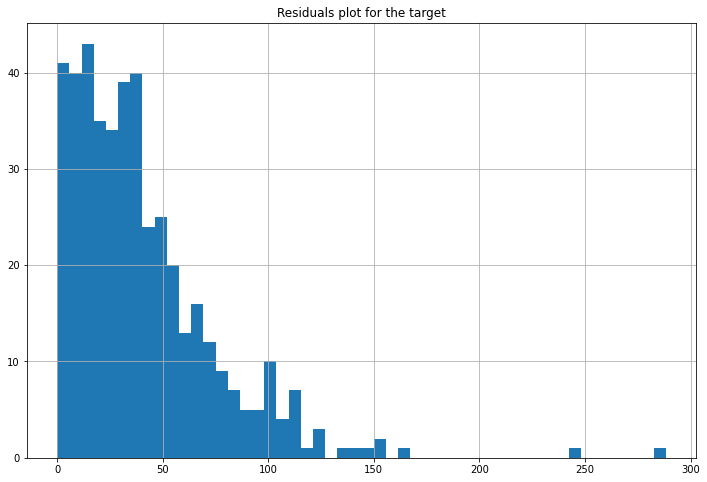

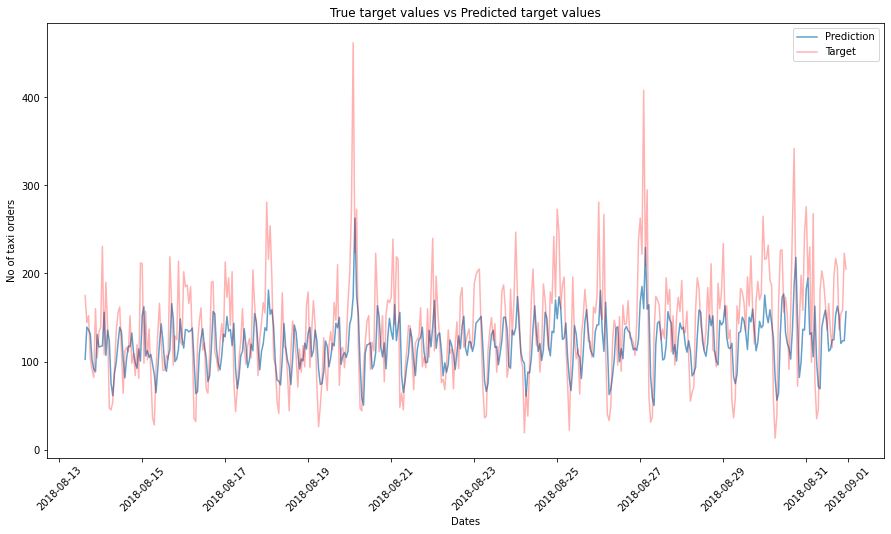

In [46]:
%%time
# Instantiate a linear regression model
lr_model = LinearRegression()

# Train the model using training features and target
lr_model.fit(features_train, target_train)

# Predict the target using the test features
lr_predictions = lr_model.predict(features_test)

# Calculate RMSE metric for the model
lr_rmse = calc_rmse(target_test, lr_predictions)
print("RMSE using Linear Regression")
print("-"*50)
print("RMSE: ", lr_rmse)

# Plot the residuals for the target
plot_residuals(target_test, lr_predictions)

# Plot the true target values vs predicted target values
plot_true_vs_predictions(features_test, target_test, lr_predictions)

# OUTPUT
# RMSE using Linear Regression
# --------------------------------------------------
# RMSE using Linear Regression
# --------------------------------------------------
# RMSE:  53.26605628855383
# CPU times: user 234 ms, sys: 76.4 ms, total: 311 ms
# Wall time: 344 ms

### Random Forest Regressor Model

Let's first optimize the hyperparameters:

In [47]:
%%time

# Define hyperparameters to tune
grid = {
    "n_estimators" : list(range(30, 100, 10)),
    "max_depth" : list(range(2, 8)),
}

# Instantiate a Random Forest Regressor model 
rfr_model = RandomForestRegressor(random_state = 12345)

# Define the grid search cv
grid_search_cv_rfr = GridSearchCV(estimator=rfr_model, param_grid=grid, scoring="neg_mean_squared_error", cv=tscv)

# Execute search
grid_search_cv_rfr.fit(features_train, target_train)

# Print result
print('The best hyperparameters are: ', grid_search_cv_rfr.best_params_)

# OUTPUT
# The best hyperparameters are:  {'max_depth': 7, 'n_estimators': 80}
# CPU times: user 1min 23s, sys: 158 ms, total: 1min 23s
# Wall time: 1min 23s

The best hyperparameters are:  {'max_depth': 7, 'n_estimators': 80}
CPU times: user 1min 23s, sys: 158 ms, total: 1min 23s
Wall time: 1min 23s


Now, we've got the best hyperparameters for Random Forest Regressor model. We'll use that and train, predict and evaluate our model:

RMSE using Random Forest Regressor
--------------------------------------------------
RMSE:  48.121664575598494
CPU times: user 1.46 s, sys: 3.93 ms, total: 1.46 s
Wall time: 1.47 s


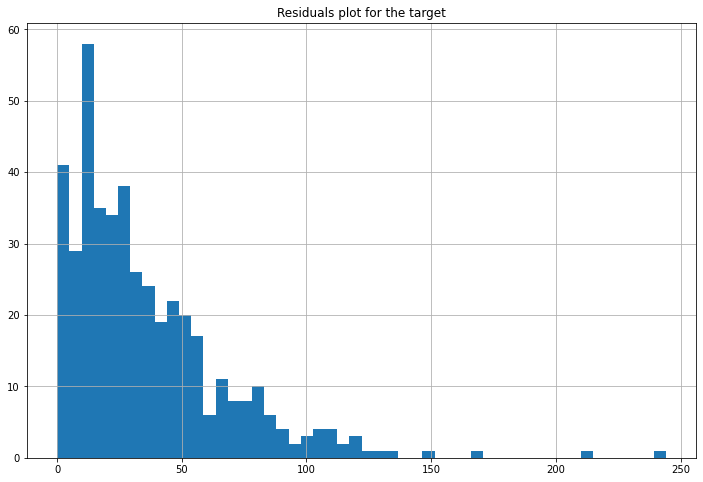

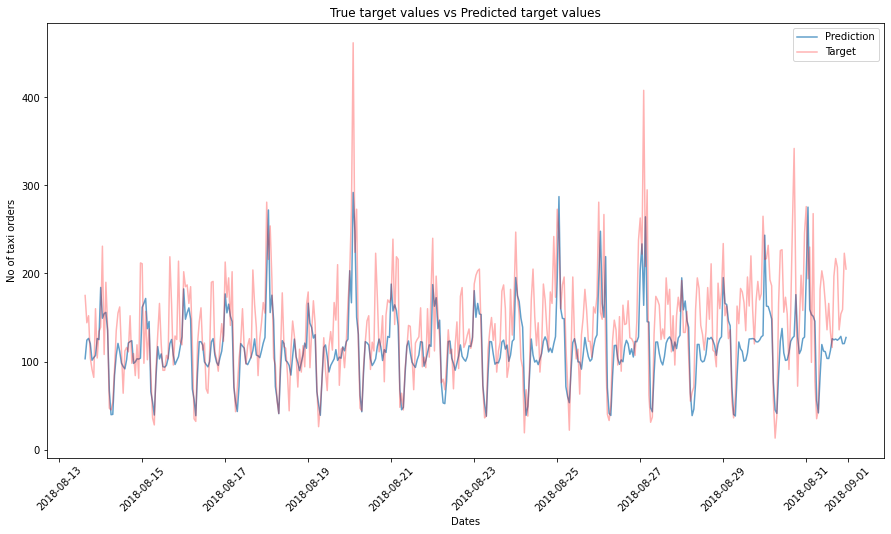

In [48]:
%%time
# Instantiate a random forest regression model
rfr_model = RandomForestRegressor(**grid_search_cv_rfr.best_params_)

# Train the model using training features and target
rfr_model.fit(features_train, target_train)

# Predict the target using the test features
rfr_predictions = rfr_model.predict(features_test)

# Calculate RMSE metric for the model
rfr_rmse = calc_rmse(target_test, rfr_predictions)
print("RMSE using Random Forest Regressor")
print("-"*50)
print("RMSE: ", rfr_rmse)

# Plot the residuals for the target
plot_residuals(target_test, rfr_predictions)

# Plot the true target values vs predicted target values
plot_true_vs_predictions(features_test, target_test, rfr_predictions)

# OUTPUT
# RMSE using Random Forest Regressor
# --------------------------------------------------
# RMSE:  48.121664575598494
# CPU times: user 1.46 s, sys: 3.93 ms, total: 1.46 s
# Wall time: 1.47 s

### LightGBM Regressor Model

LightGBM is an open-source gradient boosting framework that based on tree learning algorithm and designed to process data faster and provide better accuracy. It can handle large datasets with lower memory usage and supports distributed learning. 

Let's first optimize the hyperparameters:

In [49]:
%%time

# Define hyperparameters to tune
grid_lgbm = {
    'learning_rate': [0.001, 0.01, 0.05, 0.1],
    'n_estimators': list(range(30, 101, 10)),
}

# Instantiate a LightGBM Regressor model 
lgbm_model = LGBMRegressor(random_state=12345)

# Define the grid search cv
grid_search_cv_lgbm = GridSearchCV(estimator=lgbm_model, param_grid=grid_lgbm, scoring="neg_mean_squared_error", cv=tscv)

# Execute search
grid_search_cv_lgbm.fit(features_train, target_train)

# Print result
print('The best hyperparameters are: ', grid_search_cv_lgbm.best_params_)

# OUTPUT
# The best hyperparameters are:  {'learning_rate': 0.05, 'n_estimators': 100}
# CPU times: user 42.7 s, sys: 679 ms, total: 43.4 s
# Wall time: 43.7 s

The best hyperparameters are:  {'learning_rate': 0.05, 'n_estimators': 100}
CPU times: user 42.7 s, sys: 679 ms, total: 43.4 s
Wall time: 43.7 s


Now, we've got the best hyperparameters for LightGBM Regressor model . We'll use that and train, predict and evaluate our model:

RMSE using LightGBM Regressor model
--------------------------------------------------
RMSE:  44.617023219823544
CPU times: user 464 ms, sys: 3.75 ms, total: 468 ms
Wall time: 478 ms


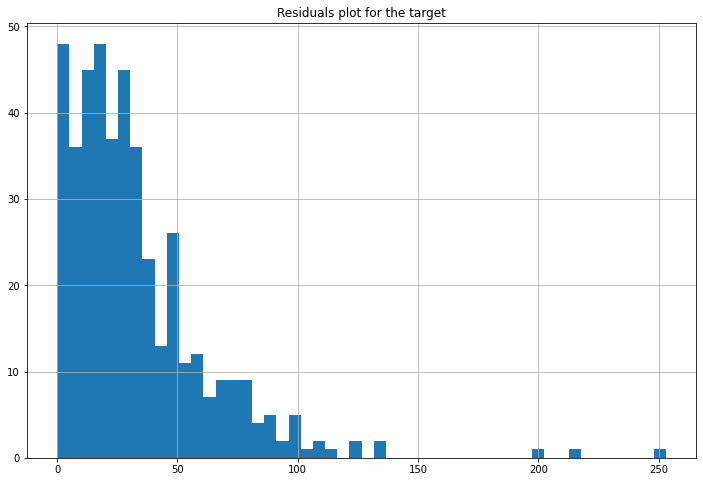

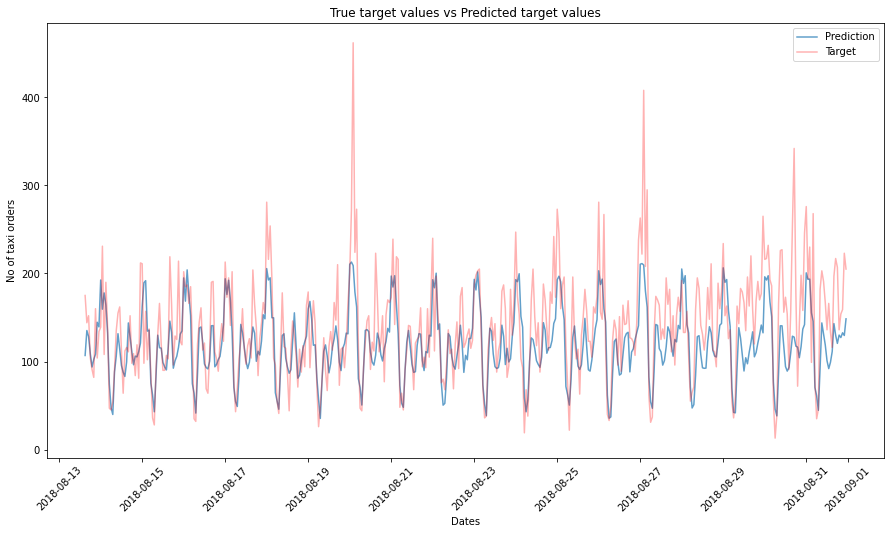

In [50]:
%%time

# Instantiate a LightGBM Regressor model
lgbm_model = LGBMRegressor(**grid_search_cv_lgbm.best_params_)

# Train the model using training features and target
lgbm_model.fit(features_train, target_train)

# Predict the target using the test features
lgbm_predictions = lgbm_model.predict(features_test)

# Calculate RMSE metric for the model
lgbm_rmse = calc_rmse(target_test, lgbm_predictions)
print("RMSE using LightGBM Regressor model")
print("-"*50)
print("RMSE: ", lgbm_rmse)

# Plot the residuals for the target
plot_residuals(target_test, lgbm_predictions)

# Plot the true target values vs predicted target values
plot_true_vs_predictions(features_test, target_test, lgbm_predictions)

# OUTPUT
# RMSE using LightGBM Regressor model
# --------------------------------------------------
# RMSE:  44.617023219823544
# CPU times: user 464 ms, sys: 3.75 ms, total: 468 ms
# Wall time: 478 ms

### CatBoost Regressor Model

CatBoost is a relatively new open-source machine learning algorithm, developed in 2017 by Yandex. One of CatBoost’s core edges is its ability to integrate a variety of different data types, such as images, audio, or text features into one framework.

References
- [CatBoost regression in 6 minutes](https://towardsdatascience.com/catboost-regression-in-6-minutes-3487f3e5b329)

Let's optimize the hyperparameters first:

In [51]:
%%time

# Define hyperparameters to tune
grid_cb = {
    'learning_rate': [0.001, 0.01, 0.05, 0.1],
    'depth': [4, 6, 10],
}

# Instantiate a CatBoost Regressor model 
cb_model = CatBoostRegressor(logging_level='Silent', iterations=100, loss_function='RMSE', random_state = 12345)

# Define the grid search cv
grid_search_cv_cb = GridSearchCV(estimator=cb_model, param_grid=grid_cb, scoring="neg_mean_squared_error", cv=tscv)

# Execute search
grid_search_cv_cb.fit(features_train, target_train)

# Print result
print('The best hyperparameters are: ', grid_search_cv_cb.best_params_)

# OUTPUT
# The best hyperparameters are:  {'depth': 6, 'learning_rate': 0.1}
# CPU times: user 1min 2s, sys: 184 ms, total: 1min 2s
# Wall time: 1min 8s

The best hyperparameters are:  {'depth': 6, 'learning_rate': 0.1}
CPU times: user 1min 2s, sys: 184 ms, total: 1min 2s
Wall time: 1min 8s


Now, we've got the best hyperparameters for CatBoost Regressor model. We'll use that and train, predict and evaluate our model:

RMSE using CatBoost Regressor model 
--------------------------------------------------
RMSE:  43.620955116985606
CPU times: user 4.05 s, sys: 12.5 ms, total: 4.06 s
Wall time: 4.15 s


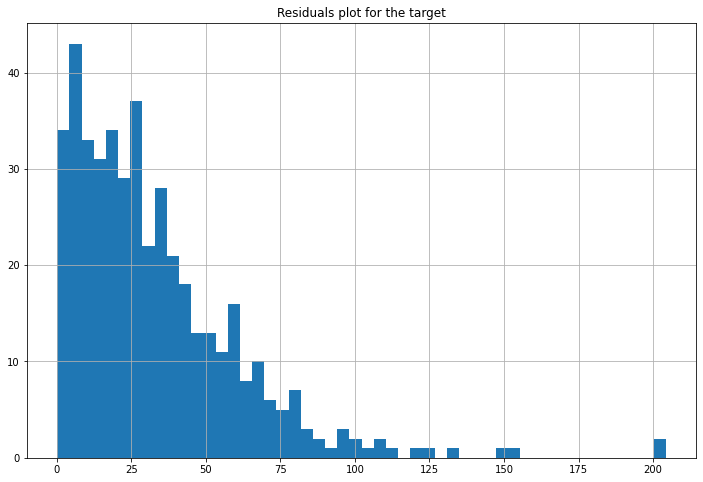

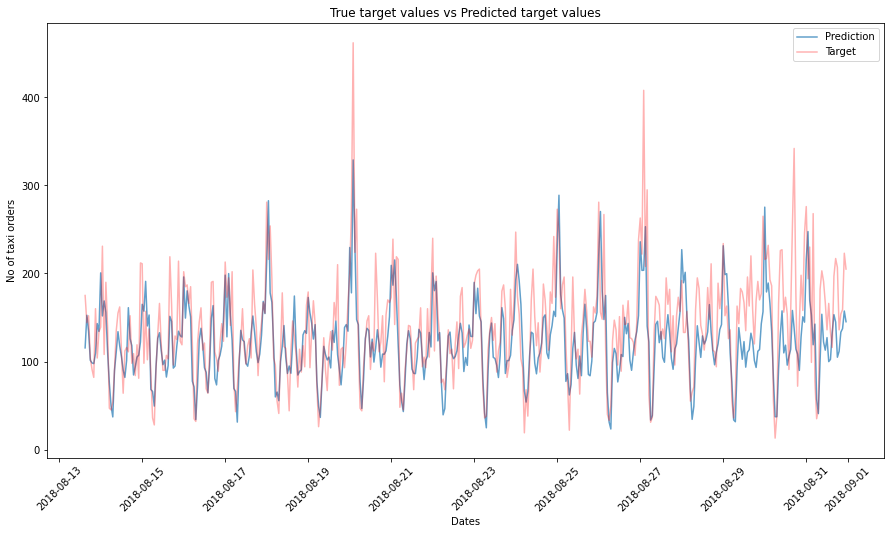

In [52]:
%%time
# Instantiate a CatBoost Regressor model 
cb_model = CatBoostRegressor(**grid_search_cv_cb.best_params_)

# Train the model using training features and target
cb_model.fit(features_train, target_train, verbose=False)

# Predict the target using the test features
cb_predictions = cb_model.predict(features_test)

# Calculate RMSE metric for the model
cb_rmse = calc_rmse(target_test, cb_predictions)
print("RMSE using CatBoost Regressor model ")
print("-"*50)
print("RMSE: ", cb_rmse)

# Plot the residuals for the target
plot_residuals(target_test, cb_predictions)

# Plot the true target values vs predicted target values
plot_true_vs_predictions(features_test, target_test, cb_predictions)

# OUTPUT
# RMSE using CatBoost Regressor model 
# --------------------------------------------------
# RMSE:  43.620955116985606
# CPU times: user 4.05 s, sys: 12.5 ms, total: 4.06 s
# Wall time: 4.15 s

### XGBoost Regressor Model

Extreme Gradient Boosting (XGBoost) is an open-source library that provides an efficient and effective implementation of the gradient boosting algorithm. Let's optimize the hyperparameters first:

In [53]:
%%time

# Define hyperparameters to tune
grid_xgb = {
    'learning_rate': [0.001, 0.01, 0.05, 0.1],
    'max_depth': [4, 6, 10],
    'n_estimators': [50, 100, 200]
}

# Instantiate a XGBoost Regressor model 
xgb_model = XGBRegressor(random_state = 12345)

# Define the grid search cv
grid_search_cv_xgb = GridSearchCV(estimator=xgb_model, param_grid=grid_xgb, scoring="neg_mean_squared_error", cv=tscv)

# Execute search
grid_search_cv_xgb.fit(features_train, target_train)

# Print result
print('The best hyperparameters are: ', grid_search_cv_xgb.best_params_)

# OUTPUT
# The best hyperparameters are:  {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}
# CPU times: user 6min 14s, sys: 2.79 s, total: 6min 17s
# Wall time: 6min 20s

The best hyperparameters are:  {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}
CPU times: user 6min 14s, sys: 2.79 s, total: 6min 17s
Wall time: 6min 20s


Now, we'll train, predict and evaluate our model:

RMSE using XGBoost Regressor model
--------------------------------------------------
RMSE:  45.24825681741491
CPU times: user 3.5 s, sys: 32 ms, total: 3.54 s
Wall time: 3.57 s


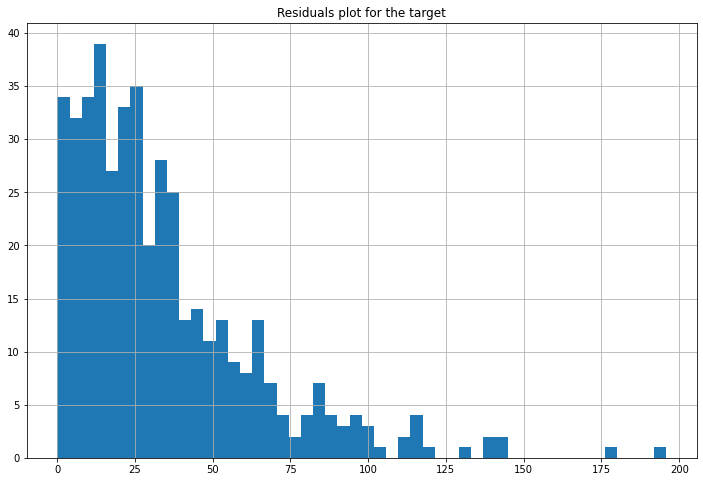

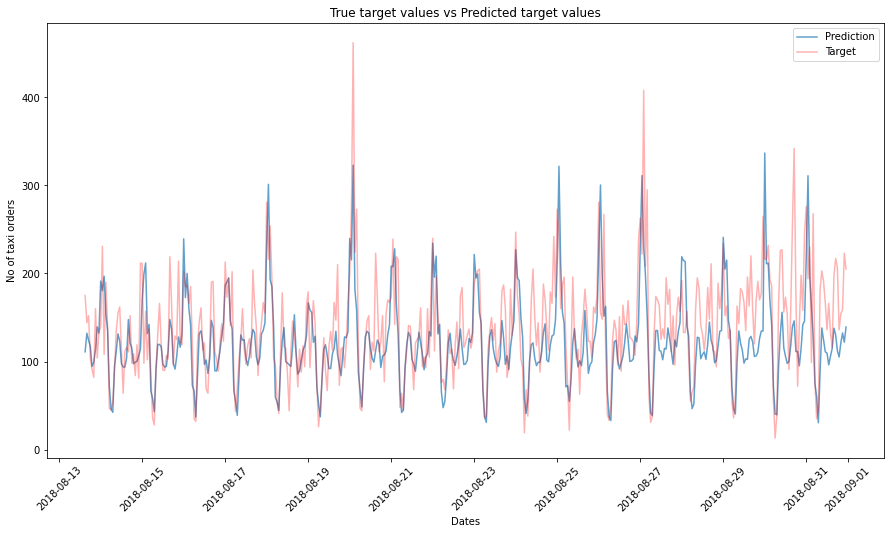

In [54]:
%%time
# Instantiate a XGBoost Regressor model 
xgb_model = XGBRegressor(**grid_search_cv_xgb.best_params_)

# Train the model using training features and target
xgb_model.fit(features_train, target_train)

# Predict the target using the test features
xgb_predictions = xgb_model.predict(features_test)

# Calculate RMSE metric for the model
xgb_rmse = calc_rmse(target_test, xgb_predictions)
print("RMSE using XGBoost Regressor model")
print("-"*50)
print("RMSE: ", xgb_rmse)

# Plot the residuals for the target
plot_residuals(target_test, xgb_predictions)

# Plot the true target values vs predicted target values
plot_true_vs_predictions(features_test, target_test, xgb_predictions)

# OUTPUT
# RMSE using XGBoost Regressor model
# --------------------------------------------------
# RMSE:  45.24825681741491
# CPU times: user 3.5 s, sys: 32 ms, total: 3.54 s
# Wall time: 3.57 s

# 8. Model Testing <a id='model-testing'></a>  
[Back to Contents](#contents)

### Baseline Model

Let's create a baseline model and use that for sanity test of the best model:

In [55]:
# Baseline model using median no of taxi orders
print('Median no of taxi orders:', target_test.median())
pred_median = np.ones(target_test.shape) * target_train.median()
print('RMSE:', calc_rmse(target_test, pred_median))

Median no of taxi orders: 135.0
RMSE: 87.24205906985632


### Select the best model

Let's summarize the performances of all the models in a table like so:

| Models            | Total secs required to tune hyper parameters | Total secs required to train the model | RMSE Score         |
|:-------------------|:----------------------------------------------|:----------------------------------------|:--------------------|
| Linear Regression | 0                                            | 0.344 secs                             | 53.26605628855383  |
| Random Forest     | 83 secs                                      | 1.47 secs                              | 48.121664575598494 |
| LightGBM          | 43.7 secs                                    | 0.478 secs                             | 44.617023219823544 |
| CatBoost          | 68 secs                                      | 4.15 secs                              | 43.620955116985606 |
| XGBoost           | 380 secs                                     | 3.57 secs                              | 45.24825681741491  |

From the above summary, we can easily see that **Cat Boost model performs the best on the basis of the RMSE metric**. And also, it performs way better than the baseline model above.

# 8. Conclusion <a id='conclusion'></a>  
[Back to Contents](#contents)

In this project, we embarked on a mission to enhance the operational efficiency of Sweet Lift Taxi Company by predicting taxi demand at airports during peak hours. Our objective was to develop a predictive model that could accurately estimate the number of taxi orders for the next hour, ultimately enabling the company to optimize its services and attract more drivers during high-demand periods.  

We started by exploring and analyzing the provided time series data, which spanned from March 1, 2018, to August 31, 2018. The dataset contained no missing values and consisted of a single column, num_orders, representing the number of taxi orders. We experimented with various machine learning models, including Linear Regression, Random Forest, LightGBM, CatBoost, and XGBoost. These models were evaluated based on their performance metrics, including the Root Mean Square Error (RMSE), which served as our primary evaluation criterion.

To optimize model performance, we tuned hyperparameters for each model, finding the best settings to achieve accurate predictions. This process varied in duration for each model. In conclusion, the CatBoost model emerged as the top-performing model for predicting taxi demand at airports, surpassing all other models in terms of the RMSE metric. This means it provides the most accurate predictions of taxi order counts for the next hour.